In [ ]:
## 1. Volatility Regime Filtering Objective:
# In this notebook, I test whether volatility can improve trade selectivity as a regime filter.
# Instead of changing the predictive model, I keep the optimized long-short framework from Notebook 7 and only allow trades when the market is in specific volatility conditions.
# The goal is to evaluate whether filtering by volatility can improve risk-adjusted returns, reduce unnecessary trades, and strengthen overall strategy robustness.

In [17]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [ ]:
## 2. Set project paths Load saved outputs from previous Notebooks
project_root = Path.cwd().parent
processed_data_path = project_root / "data" / "processed"
strategy_vol_opt = pd.read_csv(processed_data_path / "notebook_07_strategy_refinement" / "strategy_vol_opt.csv", index_col=0)
strategy_vol_opt_cum = pd.read_csv(processed_data_path / "notebook_07_strategy_refinement" / "strategy_vol_opt_cum.csv", index_col=0)
threshold_optimization = pd.read_csv(processed_data_path / "notebook_07_strategy_refinement" / "threshold_optimization.csv")
clean_close_prices = pd.read_csv(processed_data_path / "notebook_02_data_prep" / "clean_close_prices.csv", index_col=0)
ML_dataset = pd.read_csv(processed_data_path / "notebook_05_model_outputs" / "ML_dataset.csv", index_col=0)

In [3]:
## 3. Recreate 10-day volatility feature from SPY price
spy_price = clean_close_prices["SPY"]
vol_feature =  spy_price.pct_change().rolling(10).std().to_frame(name="10d_vol")
vol_feature.head()

,10d_vol
Date,
2018-01-02,NaN
2018-01-03,NaN
2018-01-04,NaN
2018-01-05,NaN
2018-01-08,NaN


In [4]:
## 4. Align volatility feature to optimized strategy dates
vol_test = vol_feature.loc[strategy_vol_opt.index].copy()
aligned_dates =  strategy_vol_opt.join(vol_test ,how="inner")
strategy_vol_opt = aligned_dates.drop(columns = ["10d_vol"])
vol_test = aligned_dates[["10d_vol"]]
vol_test["10d_vol"].describe()

count    404.000000
mean       0.008997
std        0.006520
min        0.002740
25%        0.005724
50%        0.007824
75%        0.009964
max        0.046654
Name: 10d_vol, dtype: float64

In [5]:
print("Volatility sample period:", vol_test.index.min(), "to", vol_test.index.max())
print("Strategy sample period:", strategy_vol_opt.index.min(), "to", strategy_vol_opt.index.max())

Volatility sample period: 2024-08-26 to 2026-04-07
Strategy sample period: 2024-08-26 to 2026-04-07


In [6]:
## 5. Redefine high-low volatility thresholds
low_vol_threshold = vol_test["10d_vol"].quantile(0.25)
high_vol_threshold = vol_test["10d_vol"].quantile(0.75)
print("Low-vol threshold:", round(low_vol_threshold * 100, 4), "%")
print("High-vol threshold:", round(high_vol_threshold * 100, 4), "%")

Low-vol threshold: 0.5724 %
High-vol threshold: 0.9964 %


In [7]:
## 6. Create volatility regime filters
low_vol_filter = (vol_test["10d_vol"] <= low_vol_threshold).astype(int)
high_vol_filter = (vol_test["10d_vol"] >= high_vol_threshold).astype(int)
filter_df = pd.DataFrame({"10d_vol": vol_test["10d_vol"],
                         "low_vol_filter": low_vol_filter,
                         "high_vol_filter": high_vol_filter}, index=vol_test.index)
filter_df.head()

,10d_vol,low_vol_filter,high_vol_filter
Date,,,
2024-08-26,0.008217,0,0
2024-08-27,0.007222,0,0
2024-08-28,0.007811,0,0
2024-08-29,0.005938,0,0
2024-08-30,0.006532,0,0


In [8]:
## 7. Apply volatility regime filters to optimized baseline position
baseline_executed_position = strategy_vol_opt["executed_position"] if "executed_position" in strategy_vol_opt.columns else strategy_vol_opt["position"]
low_vol_executed_position = baseline_executed_position * filter_df["low_vol_filter"]
high_vol_executed_position = baseline_executed_position * filter_df["high_vol_filter"]

In [9]:
## 8. Recompute filtered strategy returns and benchmark returns with simulated transaction cost
cost_per_trans = 0.0005
spy_returns = clean_close_prices["SPY"].pct_change().fillna(0)
spy_test_returns = spy_returns.loc[baseline_executed_position.index]

baseline_trades = baseline_executed_position.diff().abs().fillna(0)
low_vol_trades = low_vol_executed_position.diff().abs().fillna(0)
high_vol_trades = high_vol_executed_position.diff().abs().fillna(0)

baseline_returns = baseline_executed_position * spy_test_returns - cost_per_trans * baseline_trades
low_vol_returns = low_vol_executed_position * spy_test_returns - cost_per_trans * low_vol_trades
high_vol_returns = high_vol_executed_position * spy_test_returns - cost_per_trans * high_vol_trades

benchmark_returns = spy_test_returns.loc[spy_test_returns.index]

In [10]:
## 9. Compute cumulative returns
cum_baseline_vol_strategy = (1 + baseline_returns).cumprod()
cum_low_vol_strategy = (1 + low_vol_returns).cumprod()
cum_high_vol_strategy = (1 + high_vol_returns).cumprod()
cum_benchmark = (1 + benchmark_returns).cumprod()

In [18]:
## 10. Evaluate baseline and filtered strategies
from src.backtest import (annualized_return, annualized_volatility, sharpe_ratio, 
                          max_drawdown, hit_rate, exposure_rate, turnover_rate)
performance_summary = pd.DataFrame({
    "Baseline": {
        "Annualized Return": annualized_return(baseline_returns),
        "Annualized Volatility": annualized_volatility(baseline_returns),
        "Sharpe Ratio": sharpe_ratio(baseline_returns),
        "Max Drawdown": max_drawdown(cum_baseline_vol_strategy),
        "Hit Rate": hit_rate(baseline_returns),
        "Exposure Rate": exposure_rate(baseline_executed_position),
        "Turnover": turnover_rate(baseline_executed_position),},
    "Low Vol Filter": {
        "Annualized Return": annualized_return(low_vol_returns),
        "Annualized Volatility": annualized_volatility(low_vol_returns),
        "Sharpe Ratio": sharpe_ratio(low_vol_returns),
        "Max Drawdown": max_drawdown(cum_low_vol_strategy),
        "Hit Rate": hit_rate(low_vol_returns),
        "Exposure Rate": exposure_rate(low_vol_executed_position),
        "Turnover": turnover_rate(low_vol_executed_position),},
    "High Vol Filter": {
        "Annualized Return": annualized_return(high_vol_returns),
        "Annualized Volatility": annualized_volatility(high_vol_returns),
        "Sharpe Ratio": sharpe_ratio(high_vol_returns),
        "Max Drawdown": max_drawdown(cum_high_vol_strategy),
        "Hit Rate": hit_rate(high_vol_returns),
        "Exposure Rate": exposure_rate(high_vol_executed_position),
        "Turnover": turnover_rate(high_vol_executed_position),},
    "Benchmark": {
        "Annualized Return": annualized_return(benchmark_returns),
        "Annualized Volatility": annualized_volatility(benchmark_returns),
        "Sharpe Ratio": sharpe_ratio(benchmark_returns),
        "Max Drawdown": max_drawdown(cum_benchmark),
        "Hit Rate": np.nan,
        "Exposure Rate": 1.0,
        "Turnover": np.nan,}})
performance_summary

,Baseline,Low Vol Filter,High Vol Filter,Benchmark
Annualized Return,0.202230,-0.012342,0.284678,0.118927
Annualized Volatility,0.159437,0.033530,0.128422,0.173347
Sharpe Ratio,1.268395,-0.368081,2.216738,0.686062
Max Drawdown,-0.104836,-0.040945,-0.072786,-0.187552
Hit Rate,0.478803,0.419643,0.445455,NaN
Exposure Rate,0.930693,0.235149,0.225248,1.000000
Turnover,0.428218,0.148515,0.195545,NaN


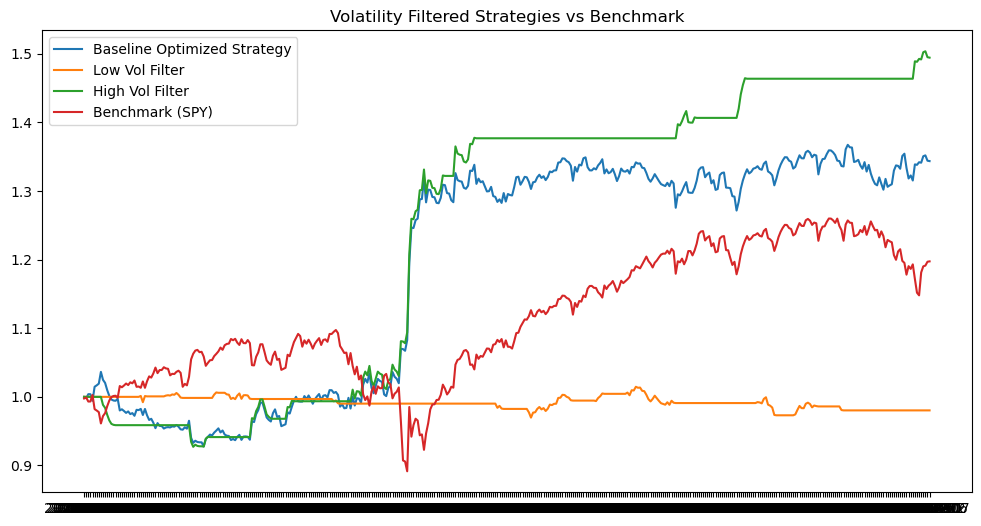

In [19]:
## 12. Visualize cumulative performance
plt.figure(figsize=(12, 6))
plt.plot(cum_baseline_vol_strategy, label="Baseline Optimized Strategy")
plt.plot(cum_low_vol_strategy, label="Low Vol Filter")
plt.plot(cum_high_vol_strategy, label="High Vol Filter")
plt.plot(cum_benchmark, label="Benchmark (SPY)")
plt.legend()
plt.title("Volatility Filtered Strategies vs Benchmark")
plt.show()

In [20]:
## 13. Check how often each regime occurs
regime_stats = pd.DataFrame({"Low Vol Days": [filter_df["low_vol_filter"].sum()],
                             "High Vol Days": [filter_df["high_vol_filter"].sum()],
                             "Total Days": [len(filter_df)]})
regime_stats["Low Vol Ratio"] = regime_stats["Low Vol Days"] / regime_stats["Total Days"]
regime_stats["High Vol Ratio"] = regime_stats["High Vol Days"] / regime_stats["Total Days"]
regime_stats.index = ["Summary"]
regime_stats

,Low Vol Days,High Vol Days,Total Days,Low Vol Ratio,High Vol Ratio
Summary,101,101,404,0.25,0.25


In [21]:
## 14. Conclusion:
# This notebook shows that my model is highly regime-dependent.
# While the baseline strategy delivers reasonable performance, it remains overly exposed to low-quality market conditions.
# By applying a volatility filter, I find that the model fails in low-volatility environments but generates strong, concentrated returns during high-volatility periods, achieving a Sharpe ratio above 2 with significantly reduced exposure.
# This confirms that volatility is not just a feature, but a gating mechanism. 
# Going forward, I will focus on refining signals within favorable regimes and developing a more structured regime-aware strategy.

In [16]:
project_root = Path.cwd().parent
nb08_path = project_root / "data" / "processed" / "notebook_08_volatility_regime_filter"
nb08_path.mkdir(parents=True, exist_ok=True)
strategy_returns = pd.DataFrame({"baseline_returns": baseline_returns,
                                 "low_vol_returns": low_vol_returns,
                                 "high_vol_returns": high_vol_returns,
                                 "benchmark_returns": benchmark_returns,
                                 "baseline_executed_position": baseline_executed_position,
                                 "low_vol_executed_position": low_vol_executed_position,
                                 "high_vol_executed_position": high_vol_executed_position,
                                 "10d_vol": filter_df["10d_vol"]})
strategy_returns.to_csv(nb08_path / "vol_regime_filtered_results.csv", index=True)
cum_filtered_results = pd.DataFrame({"cum_baseline": cum_baseline_vol_strategy,
                                     "cum_low_vol": cum_low_vol_strategy,
                                     "cum_high_vol": cum_high_vol_strategy,
                                     "cum_benchmark": cum_benchmark})
cum_filtered_results.to_csv(nb08_path / "vol_regime_filtered_cum.csv", index=True)
performance_summary.to_csv(nb08_path / "vol_regime_filtered_metrics.csv", index=True)